# Targeted Silver Sample

Oversample low frequency classes using regexes to get at least 180 examples per class.

TODO: This notebook copies many functions from the prep gold standard notebook. It's basically identical other than loading in the existing gold standard and using that first

In [64]:
%load_ext autoreload
%autoreload 2

In [37]:
# Imports
import pandas as pd
import numpy as np
import json
import re

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from tqdm.notebook import tqdm
from pandarallel import pandarallel

import boto3
import awswrangler as wr

import nltk
from collections import Counter
from nltk.corpus import words

from presidio_analyzer import AnalyzerEngine, PatternRecognizer, Pattern
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig
from faker import Faker

In [65]:
# Relative imports
import sys, os

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

from utils.utils import make_binary_label_matrix, analyze_category_distribution_from_df, plot_cooccurrence_heatmap

In [92]:
# Constants
RANDOM_STATE = 42

# AWS
AWS_REGION = "eu-west-2"
AWS_PROFILE = "data-platform-housing-prod"
DATABASE_NAME = "housing-refined-zone"
TABLE_NAME = "additional_needs_notes_reshaped"

# Paths
TAXONOMY_PATH = "../../data/output/taxonomy_autogen_v3.csv"
OUTPUT_SILVER_STANDARD_JSON_PATH = "../../data/output/silver_standard.json"
OUTPUT_SILVER_STANDARD_CSV_PATH = "../../data/output/silver_standard.csv"

# PII entites to redact
redact_entities = [
    "PERSON", 
    "EMAIL_ADDRESS", 
    "PHONE_NUMBER", 
    "DATE_TIME",
    "LOCATION",
    "UK_POSTCODE", 
    "CREDIT_CARD", 
    "IBAN_CODE", 
    "IP_ADDRESS",
    "URL"
]

pandarallel.initialize(progress_bar=True)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


## Fetch from Athena

In [40]:
def fetch_data_from_athena():
    session = boto3.Session(region_name=AWS_REGION, profile_name=AWS_PROFILE)

    sql_query = f''' SELECT DISTINCT note_id, note_content, note_category
                    FROM "{DATABASE_NAME}".{TABLE_NAME}
                    WHERE flag_no_matching_target = FALSE
                        AND flag_note_date_parse_failed = FALSE
                        AND flag_is_organisation = FALSE
                        AND flag_inactive = FALSE;
    '''

    return wr.athena.read_sql_query(sql_query, database=DATABASE_NAME, boto3_session=session, ctas_approach=False)

df = fetch_data_from_athena()

In [41]:
if not df['note_content'].str.startswith('[Category:').all():
    # Prevents this from running twice
    df['note_content'] = "[Category: " + df['note_category'] + "] " + df['note_content']
df.head()

,note_id,note_content,note_category
0,54c879b6-e430-8254-c416-25982e27d7ff,[Category: Tenancy Management] Merged Contact(...,Tenancy Management
1,59b9b955-f79f-e2fe-4947-26e658dc59c5,[Category: Tenancy Management] Call Summary; C...,Tenancy Management
2,5ffc01bb-43bb-71c6-9641-56334926f532,[Category: Tenancy Management] Callback succes...,Tenancy Management
3,73759b07-817d-ba4b-544e-1da1beb02f17,[Category: Tenancy Management] Call Summary; C...,Tenancy Management
4,73e414ab-1dd6-7ad8-2618-73bf94d40118,[Category: Tenancy Management] Call Summary; C...,Tenancy Management


## Replace acronyms

In [42]:
abbreviation_mapping = {
    # Hackney terms
    r'\bhsc\b': 'Hackney Service Centre',
    r'\bmmh\b': 'Manage My Home',
    r'\blbh\b': 'London Borough of Hackney',
    r'\brcc\b': 'Repairs Contact Centre',

    # Housing terms
    r'\btnt\b': 'tenant',
    r'\bclt\b': 'client',
    r'\btnts\b': 'tenants',
    r'\bl/h\b': 'leaseholder',
    r'\bh/o\b': 'housing officer',
    r'\btmo\b': 'Tenant Management Organisation',
    r'\bnho\b': 'neighbourhood housing officer',
    r'\bahm\b': 'area housing manager',
    r'\bhb\b': 'housing benefit',
    r'\bnosp\b': 'Notice of Seeking Possession',
    r'\bntq\b': 'Notice to Quit',
    r'\brtb\b': 'Right to Buy',
    r'\buc\b': 'Universal Credit',
    r'\basb\b': 'anti-social behaviour',
    r'\bdv\b': 'domestic violence',
    r'\bda\b': 'domestic abuse',

    # General terms
    r'\btel\b': 'telephone',
    r'\bdocs\b': 'documents',
    r'\bappt\b': 'appointment',
    r'\bacct\b': 'account',
    r'\bbacs\b': 'bank transfer',
    r'\binfo\b': 'information',
    r'\borg\b': 'organisation',
    r'\bsms\b': 'text message',
    r'\bmsg\b': 'message',
    r'\bcctv\b': 'camera',
    r'\bgp\b': 'general practitioner',
    r'\bpls\b': 'please',
    r'\brecd\b': 'received',
    r'\basap\b': 'as soon as possible',
    r'\bpls\b': 'please',
    r'\bcert\b': 'certificate',
    r'\bvm\b': 'voicemail',
}

In [43]:
acronym_substitution_patterns = [(re.compile(p, re.IGNORECASE), r) for p, r in abbreviation_mapping.items()]

def normalize_acronyms(text):
    if pd.isna(text):
        return text
    for pattern, replacement in acronym_substitution_patterns:
        text = pattern.sub(replacement, text)
    return text

df['note_content'] = df['note_content'].parallel_apply(normalize_acronyms)

## Apply regexes (same as prep_gold_standard)

In [44]:
taxonomy = pd.read_csv(TAXONOMY_PATH)

In [45]:
category_regex_patterns = [(row.cat_label, re.compile(row.regex, re.IGNORECASE)) for row in taxonomy.itertuples()] # type: ignore

def flag_category_matches(series):
    """
    Apply all category regexes to a pandas Series of texts.
    Returns a DataFrame of boolean flags.
    """
    def apply_all_categories(text):
        return {label: bool(pattern.search(text)) for label, pattern in category_regex_patterns}

    results = series.fillna('').parallel_apply(apply_all_categories)
    return pd.DataFrame(results.tolist())

df = df.join(flag_category_matches(df['note_content']))

## Import Gold Standard & Get Counts

In [ ]:
with open("../../data/output/gold_standard.json", "r") as f:
    gold_data = json.load(f)

In [68]:
existing_cat_counts = make_binary_label_matrix(gold_data, taxonomy).sum(axis=0).sort_values(ascending=True)
existing_cat_counts

communication_digital_exclusion                32
care_care_setting                              40
cautions_asbo_or_injunction_obtained           44
communication_fluency_in_english               48
property_level_infestation                     50
property_level_property_adapted                53
safety_risk_gas_capped                         54
disability_sensory                             58
health_breathing_respiratory_problems          61
health_neurodiversity_learning_disability      63
health_cognitive_impairment                    65
cautions_physical_abuse_or_threat_of           67
health_terminally_ill                          67
health_substance_misuse                        68
care_has_caring_responsibility                 72
safety_risk_firerelated_risks                  74
housing_conditions_utilities                   85
housing_conditions_hoarding                    94
cautions_verbal_abuse_or_threat_of             96
safety_risk_risk_of_exploitation              102


## Define Target Counts

In [72]:
TARGET_PER_CAT = 150
sampled_ids = set([r['id'] for r in gold_data])
sampled_data = []

for cat, existing_count in existing_cat_counts.items():
    pool = df[df[cat] & ~df['note_id'].isin(sampled_ids)] # In the category and not already sampled
    n = min(len(pool), TARGET_PER_CAT - existing_count)
    if n > 0:
        print(f"Collecting {n} samples from {cat}. Existing count: {existing_count}, Pool: {len(pool)}, Ideal target: {TARGET_PER_CAT - existing_count}")
        sample = pool.sample(n=n, random_state=RANDOM_STATE) # Random sample
        sampled_data.append(sample)
        sampled_ids.update(sample['note_id'].tolist())

# Combine and shuffle
silver_sample = pd.concat(sampled_data).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [79]:
len(silver_sample)

1717

## Analyse combined distribution


,label,frequency,IRLbl
0,property_level_disrepair_damp_mould,570,1.000000
1,safety_risk_antisocial_behaviour,475,1.200000
2,health_medical_condition,315,1.809524
3,health_mental_health,267,2.134831
4,care_social_care_involvement,266,2.142857
5,disability_requires_adapted_property,251,2.270916
6,health_care_setting,211,2.701422
7,life_events_life_events,200,2.850000
8,mobility_mobility_physical,199,2.864322
9,cautions_verbal_abuse_or_threat_of,198,2.878788


,Metric,Value
0,MeanIR,3.23
1,MaxIR,7.12
2,CVIR,0.32


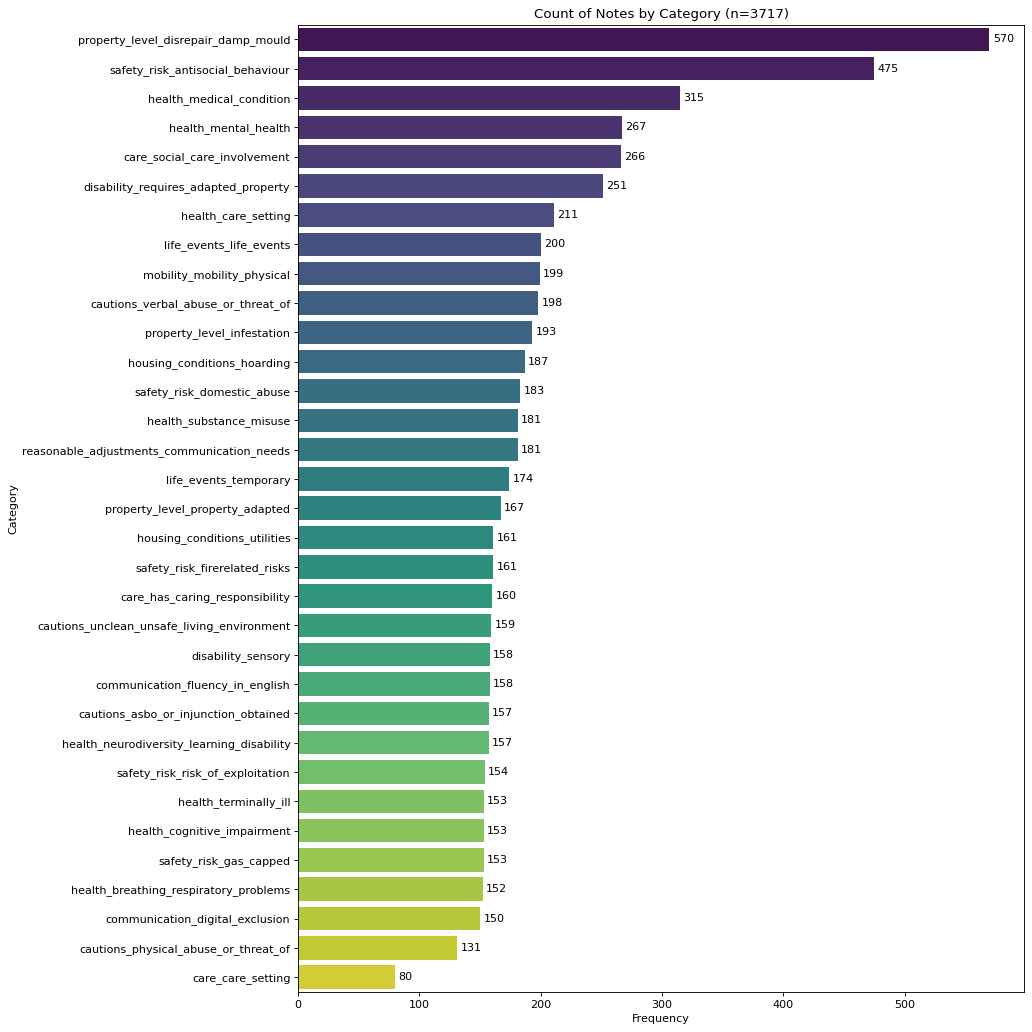

In [82]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_df(
    df = pd.concat([make_binary_label_matrix(gold_data, taxonomy), silver_sample]).drop(columns=['note_id', 'note_content', 'note_category']), 
    taxonomy_df=taxonomy, 
    log_scale=False)
display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)

## PII Redaction

In [83]:
def clean_data(df):
    # Anonymise & track names that were replaced
    def anonymize_and_extract_spans(text):
        if not isinstance(text, str):
            return pd.Series({'note_content': text, 'fake_name_spans': []})
            
        # Analyze
        results = analyzer.analyze(text=text, entities=redact_entities, language='en')
        
        # Anonymize
        anonymized = anonymizer.anonymize(
            text=text,
            analyzer_results=results, # type: ignore
            operators=operators
        )
        
        fake_spans = []
        for item in anonymized.items:
            if item.entity_type == 'PERSON':
                # Highlight replaced names as fake
                fake_spans.append({
                    'start': item.start,
                    'end': item.end,
                    'text': item.text, 
                    'labels': ['Pseudonym'] 
                })
        
        return pd.Series({
            'note_content': anonymized.text,
            'fake_name_spans': fake_spans
        })

    # Set up engines
    fake = Faker('en')
    Faker.seed(RANDOM_STATE)

    analyzer = AnalyzerEngine()
    anonymizer = AnonymizerEngine()

    # Regex matcher for UK postcodes
    uk_postcode_pattern = Pattern(
        name="uk_postcode_regex", 
        regex=r"\b([Gg][Ii][Rr] 0[Aa]{2})|((([A-Za-z][0-9]{1,2})|(([A-Za-z][A-Ha-hJ-Yj-y][0-9]{1,2})|(([A-Za-z][0-9][A-Za-z])|([A-Za-z][A-Ha-hJ-Yj-y][0-9][A-Za-z]?))))\s?[0-9][A-Za-z]{2})\b", 
        score=0.85
    )
    uk_postcode_recognizer = PatternRecognizer(
        supported_entity="UK_POSTCODE", 
        patterns=[uk_postcode_pattern]
    )
    analyzer.registry.add_recognizer(uk_postcode_recognizer)

    # Replace names with fake names
    consistent_name_map = {}
    def get_consistent_fake_name(text):
        if text not in consistent_name_map:
            consistent_name_map[text] = fake.name()
        return consistent_name_map[text]

    # Define operator for each entity type
    operators = {
        "PERSON": OperatorConfig("custom", {"lambda": get_consistent_fake_name}),
        "DEFAULT": OperatorConfig("replace") # Automatically replaces with e.g., <PHONE_NUMBER>
    }

    tqdm.pandas() # Enable pandas progress_apply (for progress bar)
    scrubbed_df = df.copy()
    scrubbed_df[['note_content', 'fake_name_spans']] = scrubbed_df['note_content'].progress_apply(anonymize_and_extract_spans)
    return scrubbed_df

In [84]:
scrubbed_df = clean_data(silver_sample)
scrubbed_df.head()

0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


  0%|          | 0/1717 [00:00<?, ?it/s]

,note_id,note_content,note_category,care_care_setting,care_has_caring_responsibility,care_social_care_involvement,cautions_asbo_or_injunction_obtained,cautions_physical_abuse_or_threat_of,cautions_unclean_unsafe_living_environment,cautions_verbal_abuse_or_threat_of,...,mobility_mobility_physical,property_level_property_adapted,property_level_disrepair_damp_mould,property_level_infestation,safety_risk_antisocial_behaviour,safety_risk_domestic_abuse,safety_risk_firerelated_risks,safety_risk_gas_capped,safety_risk_risk_of_exploitation,fake_name_spans
0,9a8d7c3c-ea7e-4bca-8e29-24030651503d,[Category: estateManagement] Home Visit Prope...,estateManagement,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,[]
1,362ae0c8-377b-46a0-8e88-5c2820c25b7f,[Category: tenureManagement] <DATE_TIME> atten...,tenureManagement,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,[]
2,c756a0c5-be85-aa28-4848-e9996a6943bd,[Category: Service Charge] [Process: 1668585] ...,Service Charge,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
3,41a67db4-8608-a35e-241c-2506d49dc982,[Category: Tenancy Management] Applicant is a ...,Tenancy Management,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,"[{'start': 1673, 'end': 1684, 'text': 'Noah Rh..."
4,dbf7219f-ef42-4946-a614-bdbbd114f6eb,[Category: estateManagement] Daniel Wagner cal...,estateManagement,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,"[{'start': 142, 'end': 157, 'text': 'Angie Hen..."


## Span Annotation

In [88]:
def generate_label_studio_json(df):
    # Construct regexes for ANs & roles & compile
    person_role_regex = r"(?i)\b(tenant|tenants|leaseholder|leaseholders|resident|residents|child|children|son|daughter|partner|wife|husband|mother|father|caller|applicant|neighbour|neighbor|neighbours|neighbor)\b" # common housing roles
    compiled_role_regex = re.compile(person_role_regex)
    compiled_category_regex = {row.cat_label: re.compile(row.regex) for row in taxonomy.itertuples()} # type: ignore

    # Loop through dataframe rows
    label_studio_tasks = []
    for index, row in tqdm(df.iterrows()):
        note_content = str(row['note_content'])
        note_id = str(row['note_id'])
        
        identified_labels = []
        
        # --- AN Tags ---
        for cat_key, compiled_regex in compiled_category_regex.items():
            for match in compiled_regex.finditer(note_content):
                identified_labels.append({
                    "from_name": "need_labels",  # Needs to match Label Studio XML
                    "to_name": "text",
                    "type": "labels",
                    "value": {
                        "start": match.start(), # Extract the specific span - didn't do with the whole dataset as it is expensive.
                        "end": match.end(),
                        "text": match.group(),
                        "labels": [cat_key]
                    }
                })

        # --- Role Labels ---
        for match in compiled_role_regex.finditer(note_content):
            identified_labels.append({
                "from_name": "entity_labels",  # Needs to match Label Studio XML
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(),
                    "end": match.end(),
                    "text": match.group(),
                    "labels": ["Person Role"]
                }
            })

        # --- Fake name Spans (Presidio) ---
        for span in row['fake_name_spans']:
            identified_labels.append({
                "from_name": "entity_labels", # Needs to match Label Studio XML
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": span['start'],
                    "end": span['end'],
                    "text": span['text'],
                    "labels": span['labels']
                }
            })
        
        # --- Construct label studio task ---
        task = {
            "data": {
                "note_content": note_content,
                "id": note_id
            },
            "predictions": [{
                "model_version": "pre_annotated",
                "score": 1.0,
                "result": identified_labels
            }]
        }
        
        label_studio_tasks.append(task)
    return label_studio_tasks

In [89]:
label_studio_tasks = generate_label_studio_json(scrubbed_df)
len(label_studio_tasks)

0it [00:00, ?it/s]

1717

In [90]:
label_studio_tasks[1]


{'data': {'note_content': '[Category: tenureManagement] <DATE_TIME> attended block  In regards to inspections and fire risk items identified. \n\nTenant advised of issue with bin collection I advised tenant to call or send a report via email. \n\nTenant also advised of a neighbour with a workshop (which is already being investigated, tenant advised the individual is on holiday. \n\nSuccessful TA completed.',
  'id': '362ae0c8-377b-46a0-8e88-5c2820c25b7f'},
 'predictions': [{'model_version': 'pre_annotated',
   'score': 1.0,
   'result': [{'from_name': 'need_labels',
     'to_name': 'text',
     'type': 'labels',
     'value': {'start': 87,
      'end': 96,
      'text': 'fire risk',
      'labels': ['safety_risk_firerelated_risks']}},
    {'from_name': 'entity_labels',
     'to_name': 'text',
     'type': 'labels',
     'value': {'start': 117,
      'end': 123,
      'text': 'Tenant',
      'labels': ['Person Role']}},
    {'from_name': 'entity_labels',
     'to_name': 'text',
     'ty

## Export Silver Standard

In [93]:
# Annotated examples
with open(OUTPUT_SILVER_STANDARD_JSON_PATH, "w") as f:
    json.dump(label_studio_tasks, f, indent=2)

In [94]:
# Data without annotations
scrubbed_df.to_csv(OUTPUT_SILVER_STANDARD_CSV_PATH, index=False) 